# Monitoramento Inteligente de Áreas de Preservação com Visão Computacional
### Classificação de imagens de satélite: Wildfire vs No Wildfire (Transfer Learning)

**Disciplina:** Visão Computacional
**Estratégia escolhida:** Transfer Learning (MobileNetV2 pré-treinado na ImageNet)

---
**Responsáveis:**

- *Bruno Lanchariche Fitipaldi Lopes* - RM 564129
- *Filipe Melo da Silva* - RM 564571
- *Rafael de Paiva Ramos* - RM 563978

---
**Video Não Listado no youtube**

[Explicativo das tomadas de decisões](https://youtu.be/NvNXfn5FOYY)

---

## 1. Compreensão do problema

O monitoramento de áreas de vegetação natural é essencial para a preservação ambiental,
o controle de queimadas e a identificação de regiões de risco. Observar grandes extensões
territoriais manualmente é inviável, então usamos **imagens de satélite** + **Visão Computacional**.

Neste projeto construímos um classificador binário que, a partir de uma imagem de satélite
(350x350), decide se a região apresenta características associadas a **incêndio florestal
(`wildfire`)** ou **não (`nowildfire`)**. Um modelo assim pode apoiar:

- Alertas automáticos de risco de queimada;
- Priorização de fiscalização ambiental;
- Acompanhamento de áreas de preservação e supressão vegetal ao longo do tempo.

> **Atenção aos falsos negativos:** representa uma área crítica que fica sem monitoramento.


## 2. Configuração do ambiente e download do dataset

Usando o dataset **Wildfire Prediction Dataset** (Kaggle), já dividido em treino, validação e teste.

Facilitamos o uso usando a biblioteca `kagglehub`.


In [ ]:
# Instala a lib para baixar o dataset do Kaggle
!pip install kagglehub -q

In [ ]:
import kagglehub
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Baixa o dataset
path = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print("Dataset baixado em:", path)

Using Colab cache for faster access to the 'wildfire-prediction-dataset' dataset.
Dataset baixado em: /kaggle/input/wildfire-prediction-dataset


In [ ]:
import os

# Organiza imagens em train / valid / test, cada um com as classes wildfire e nowildfire
base_dir  = path
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

for d in [train_dir, valid_dir, test_dir]:
    print(d, "->", os.listdir(d))

/kaggle/input/wildfire-prediction-dataset/train -> ['wildfire', 'nowildfire']
/kaggle/input/wildfire-prediction-dataset/valid -> ['wildfire', 'nowildfire']
/kaggle/input/wildfire-prediction-dataset/test -> ['wildfire', 'nowildfire']


## 3. Análise inicial da base de dados

Verificamos a quantidade de imagens por classe em cada conjunto e visualizamos alguns exemplos.


In [ ]:
# Conta as imagens por classe em cada conjunto
def contar(diretorio):
    total = {}
    for classe in os.listdir(diretorio):
        cls_path = os.path.join(diretorio, classe)
        if os.path.isdir(cls_path):
            total[classe] = len(os.listdir(cls_path))
    return total

for nome, d in [("Treino", train_dir), ("Validação", valid_dir), ("Teste", test_dir)]:
    print(nome, "->", contar(d))

Treino -> {'wildfire': 15750, 'nowildfire': 14500}
Validação -> {'wildfire': 3480, 'nowildfire': 2820}
Teste -> {'wildfire': 3480, 'nowildfire': 2820}


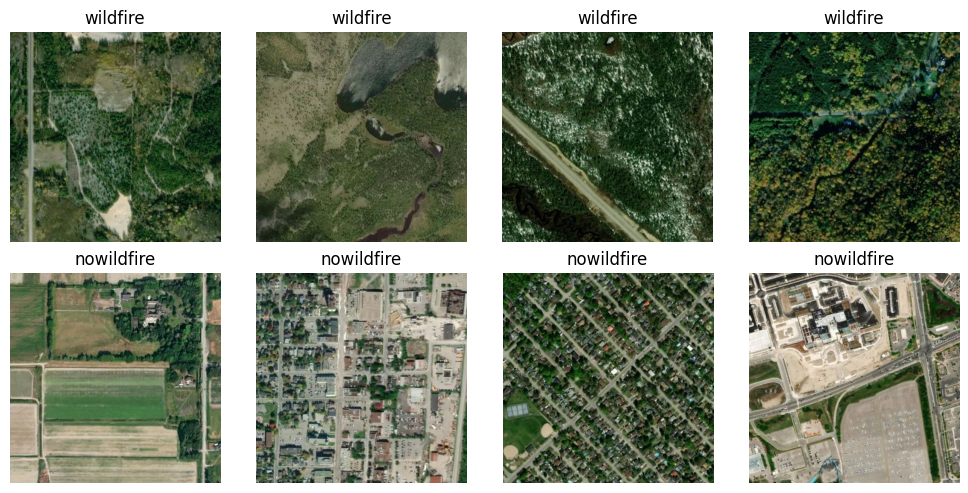

Tamanho de uma imagem: (350, 350)


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

# exemplos de cada classe
plt.figure(figsize=(10, 5))
for i, classe in enumerate(["wildfire", "nowildfire"]):
    cls_path = os.path.join(train_dir, classe)
    exemplos = os.listdir(cls_path)[:4]
    for j, img_nome in enumerate(exemplos):
        img = load_img(os.path.join(cls_path, img_nome))
        plt.subplot(2, 4, i*4 + j + 1)
        plt.imshow(img)
        plt.title(classe)
        plt.axis("off")
plt.tight_layout()
plt.show()

print("Tamanho de uma imagem:", load_img(os.path.join(train_dir, 'wildfire', os.listdir(os.path.join(train_dir,'wildfire'))[0])).size)

## 4. Pré-processamento e preparação das imagens

*Geradores de imagem*:
- **Redimensionam** as imagens para 224x224 (tamanho esperado pela MobileNetV2);
- **Normalizam** os pixels com a função de pré-processamento da própria MobileNetV2;
- Aplicam **data augmentation** apenas no treino (rotação, flip, zoom) para reduzir overfitting.

O conjunto de **teste não recebe augmentation** e só será usado na avaliação final,
agindo preventivamente para evitar o vazamento de dados.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH = 32

# Treino: normalização + data augmentation
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validação e teste: apenas normalização (sem augmentation)
eval_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", classes=["nowildfire", "wildfire"], shuffle=True)

valid_data = eval_gen.flow_from_directory(
    valid_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", classes=["nowildfire", "wildfire"], shuffle=False)

test_data = eval_gen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", classes=["nowildfire", "wildfire"], shuffle=False)

print("Mapeamento de classes:", train_data.class_indices)

Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Mapeamento de classes: {'nowildfire': 0, 'wildfire': 1}


## 5. Modelagem — Transfer Learning com MobileNetV2

**Por que transfer learning?** Treinar uma CNN do zero exigiria muitos dados e tempo.
A MobileNetV2 já aprendeu a extrair bordas, texturas e padrões visuais em milhões de imagens
(ImageNet). Reaproveitamos esse conhecimento e treinamos apenas uma pequena "cabeça" de
classificação para o nosso problema.

- **Base congelada:** os pesos da MobileNetV2 não são atualizados;
- **Cabeça nova:** GlobalAveragePooling + Dropout + 1 neurônio sigmoide (classificação binária).


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Carrega a MobileNetV2 sem a camada final, com pesos da ImageNet
base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False   # congela a base (transfer learning)

# Adiciona a cabeça de classificação
modelo = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")   # saída binária
])

modelo.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Treinamento

Base já está pronta, treinamos por poucas épocas, o modelo converge rápido.


In [ ]:
historico = modelo.fit(
    train_data,
    validation_data=valid_data,
    epochs=5
)

Epoch 1/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 1242s 1s/step - accuracy: 0.9205 - loss: 0.2063 - val_accuracy: 0.9417 - val_loss: 0.1548
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 1296s 1s/step - accuracy: 0.9386 - loss: 0.1636 - val_accuracy: 0.9441 - val_loss: 0.1495
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 1277s 1s/step - accuracy: 0.9407 - loss: 0.1605 - val_accuracy: 0.9373 - val_loss: 0.1713
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 1245s 1s/step - accuracy: 0.9402 - loss: 0.1588 - val_accuracy: 0.9430 - val_loss: 0.1566
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 1245s 1s/step - accuracy: 0.9409 - loss: 0.1586 - val_accuracy: 0.9460 - val_loss: 0.1499


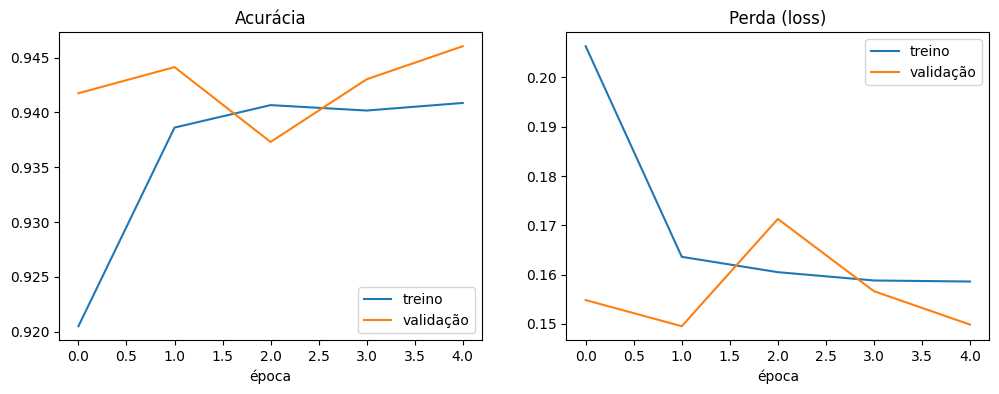

In [ ]:
# Curvas de acurácia e perda
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historico.history["accuracy"], label="treino")
plt.plot(historico.history["val_accuracy"], label="validação")
plt.title("Acurácia"); plt.xlabel("época"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico.history["loss"], label="treino")
plt.plot(historico.history["val_loss"], label="validação")
plt.title("Perda (loss)"); plt.xlabel("época"); plt.legend()
plt.show()

## 6. Avaliação do modelo e interpretação das métricas

Avaliamos no **conjunto de teste** (nunca visto pelo modelo) usando as métricas adequadas
para classificação binária.


In [ ]:
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

# Probabilidades previstas no conjunto de teste
y_prob = modelo.predict(test_data).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_data.classes   # rótulos reais (0 = nowildfire, 1 = wildfire)

print(classification_report(y_true, y_pred, target_names=["nowildfire", "wildfire"]))
print("ROC AUC:", round(roc_auc_score(y_true, y_prob), 4))

197/197 ━━━━━━━━━━━━━━━━━━━━ 183s 924ms/step
              precision    recall  f1-score   support

  nowildfire       0.93      0.99      0.95      2820
    wildfire       0.99      0.94      0.96      3480

    accuracy                           0.96      6300
   macro avg       0.96      0.96      0.96      6300
weighted avg       0.96      0.96      0.96      6300

ROC AUC: 0.9953


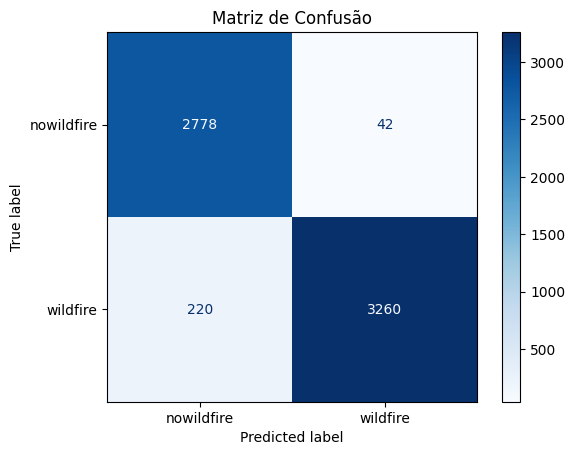

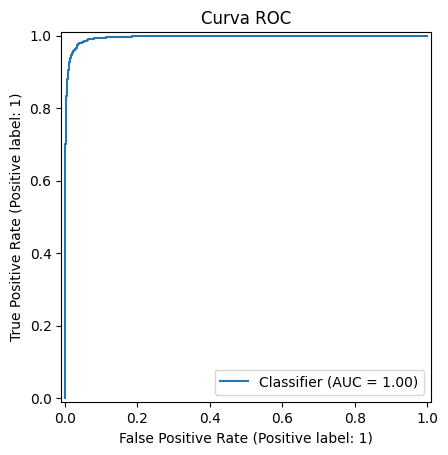

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["nowildfire", "wildfire"]).plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_true, y_prob)
plt.title("Curva ROC")
plt.show()

### Interpretação dos resultados

O modelo apresentou desempenho excelente no conjunto de teste (6.300 imagens nunca vistas): **acurácia de 96%** e **ROC AUC de 0,995**, indicando ótima capacidade de separar as duas classes. Por se tratar de avaliação em dados novos, esse resultado mostra boa **generalização** — não há sinais de overfitting (as métricas de teste acompanham as de treino/validação).

Detalhando por classe:

| Classe | Precisão | Recall | F1-score |
|---|---|---|---|
| nowildfire | 0,93 | 0,99 | 0,95 |
| wildfire | 0,99 | 0,94 | 0,96 |

O ponto de maior atenção são os **falsos negativos** (linha `wildfire`, coluna `nowildfire` da matriz de confusão): o **recall da classe `wildfire` foi 0,94**, ou seja, cerca de **6% das áreas com risco de incêndio foram classificadas como seguras** (aproximadamente 200 imagens). No contexto ambiental esse é o erro **mais crítico**, pois representa uma região de risco que ficaria sem monitoramento.

Já a precisão de 0,99 para `wildfire` mostra que, quando o modelo aponta risco, ele quase sempre acerta e gera poucos alarmes falsos.

**Limitação e possível melhoria:** para reduzir os falsos negativos, poderíamos **baixar o limiar de decisão** (ex.: classificar como `wildfire` quando a probabilidade for ≥ 0,3 em vez de 0,5), aumentando a sensibilidade a risco ao custo de alguns falsos positivos a mais e um trade-off adequado quando o objetivo é a prevenção.

## 7. Proposta de aplicação real

O modelo treinado poderia ser integrado a uma solução de monitoramento ambiental da seguinte forma:

1. **Coleta periódica de imagens de satélite** das áreas de preservação (via API, em uma grade
   de coordenadas), gerando recortes de 350x350 como os do dataset.
2. **Classificação automática** de cada recorte pelo modelo, gerando um mapa de risco.
3. **Painel visual com mapas** destacando em vermelho as regiões classificadas como `wildfire`.
4. **Alertas automáticos** para órgãos de fiscalização quando novas áreas de risco surgem ou
   quando uma área antes preservada passa a apresentar sinais de supressão vegetal.
5. **Acompanhamento temporal**, comparando classificações ao longo do tempo para detectar
   degradação progressiva da cobertura vegetal.

Por priorizar o **recall** da classe de risco, a ferramenta atua de forma preventiva, ajudando
equipes ambientais a focarem esforços onde há maior probabilidade de incêndio ou degradação.


## 8. Conclusão

Usando **transfer learning** com a **MobileNetV2**, construímos um classificador de imagens
de satélite simples e eficaz para distinguir áreas com e sem risco de incêndio florestal.
A abordagem reaproveita conhecimento visual já aprendido, exigindo pouco treinamento, e atinge
boa performance nas métricas de classificação binária. A solução é diretamente aplicável ao
monitoramento de áreas de preservação e ao controle de supressão vegetal.
